In [2]:
import pandas as pd

df = pd.read_csv("../data/amazon_reviews_processed.csv")
df = df.dropna(subset=['text_tfidf'])  # drop the 1 row that became empty after cleaning
print(df.shape)
df['sentiment'].value_counts()

(65117, 7)


sentiment
positive    47083
negative    13263
neutral      4771
Name: count, dtype: int64

In [3]:
from sklearn.model_selection import train_test_split

X = df['text_tfidf']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain distribution:\n", y_train.value_counts(normalize=True))
print("\nTest distribution:\n", y_test.value_counts(normalize=True))

Train shape: (52093,)
Test shape: (13024,)

Train distribution:
 sentiment
positive    0.723053
negative    0.203674
neutral     0.073273
Name: proportion, dtype: float64

Test distribution:
 sentiment
positive    0.723050
negative    0.203701
neutral     0.073249
Name: proportion, dtype: float64


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,   
    ngram_range=(1, 2),   
    min_df=5,             
    max_df=0.8             
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)
print("Sample features:", tfidf.get_feature_names_out()[:20])

Train TF-IDF shape: (52093, 10000)
Test TF-IDF shape: (13024, 10000)
Sample features: ['ability' 'able' 'able afford' 'able find' 'able get' 'able put'
 'able read' 'able see' 'abortion' 'abreast' 'abroad' 'absence' 'absolute'
 'absolute favorite' 'absolutely' 'absolutely love' 'absolutely loved'
 'absolutely nothing' 'absurd' 'abundance']


In [5]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)
print("Model trained.")

Model trained.


              precision    recall  f1-score   support

    negative       0.70      0.73      0.71      2653
     neutral       0.24      0.46      0.32       954
    positive       0.96      0.86      0.91      9417

    accuracy                           0.81     13024
   macro avg       0.63      0.68      0.65     13024
weighted avg       0.86      0.81      0.83     13024



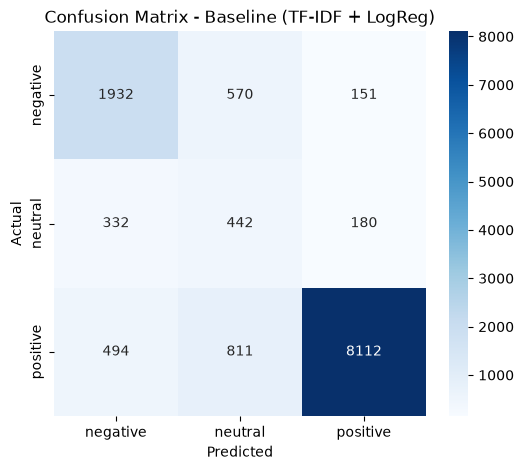

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=['negative', 'neutral', 'positive'])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative','neutral','positive'],
            yticklabels=['negative','neutral','positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Baseline (TF-IDF + LogReg)')
plt.show()

In [7]:
import joblib

joblib.dump(model, "../models/baseline_logreg.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")
print("Saved baseline model and vectorizer.")

Saved baseline model and vectorizer.
